In [1]:
import stim
import numpy as np
import pandas as pd
from tools.complete_LUT import CompleteLUT
from tools.error_vec import ErrorVectors
from tools.syndrome_mapping import SyndromeMapper
import matplotlib.pyplot as plt
import time
import sys

### Building general repetition circuit for logical 0 or 1

In [2]:
def build_repetition_circuit(distance, rounds, p, logical="0"):
    """
    Build stim repetition_code:memory circuit.

    logical='0' -> default generated circuit
    logical='1' -> apply X on all data qubits after reset
    """
    circuit = stim.Circuit.generated(
        "repetition_code:memory",
        distance=distance,
        rounds=rounds,
        before_round_data_depolarization=p,
        before_measure_flip_probability=p,
        after_reset_flip_probability=p,
    )

    if logical == "0":
        return circuit

    if logical == "1":
        data_qubits = list(range(0, 2 * distance - 1, 2))

        new_circuit = stim.Circuit()
        inserted = False

        for inst in circuit:
            new_circuit.append(inst)

            if not inserted and inst.name == "R":
                new_circuit.append("X", data_qubits)
                inserted = True

        return new_circuit

    raise ValueError("logical must be '0' or '1'")

#### Functions required for other function

In [3]:
def bits_to_int(bits):
    x = 0
    for b in bits:
        x = (x << 1) | int(b)
    return x

def majority_vote(bits):
    t = int(bits[-1])
    if sum(int(b) for b in bits) > (len(bits) // 2):
        t = 1
    elif sum(int(b) for b in bits) < (len(bits) // 2):
        t = 0
    return t


def apply_correction(data_bits, correction):
    return [int(b) ^ int(c) for b, c in zip(data_bits, correction)]

In [4]:
def deep_getsizeof(obj, seen=None):
    """
    Recursively estimate memory usage of a Python object in bytes.
    """
    if seen is None:
        seen = set()

    obj_id = id(obj)
    if obj_id in seen:
        return 0
    seen.add(obj_id)

    size = sys.getsizeof(obj)

    if isinstance(obj, dict):
        size += sum(deep_getsizeof(k, seen) + deep_getsizeof(v, seen) for k, v in obj.items())
    elif isinstance(obj, (list, tuple, set, frozenset)):
        size += sum(deep_getsizeof(i, seen) for i in obj)

    return size

#### Function to extract all measurements and dets from circuit

In [5]:
def sample_measurements_and_dets(distance, rounds, p, shots, logical):
    circuit = build_repetition_circuit(distance, rounds, p, logical=logical)

    sampler = circuit.compile_sampler()
    measurements = sampler.sample(shots=shots, bit_packed=False)

    converter = circuit.compile_m2d_converter()
    dets, obs = converter.convert(
        measurements=measurements,
        separate_observables=True,
    )

    return measurements, dets

#### Function to build limited LUT

In [6]:
def build_limited_lut(distance, rounds, max_weight, p):
    """
    Build limited LUT using tools.error_vec + tools.syndrome_mapping.
    """
    ev = ErrorVectors(distance, rounds)
    mapper = SyndromeMapper(distance, rounds)

    error_vectors = ev.combined_error_vectors(
        max_weight=max_weight,
        before_prob=p,
        after_prob=p,
    )
    return mapper.syndrome_to_min_corrections(error_vectors)

#### Function to run any LUT with input syndrome (detectors) and data qubits (last "d" measurements)

In [7]:
def logical_error_stats_for_lut(measurements, dets, lut, distance, encoded_logical):
    """
    Decode using Stim detector outputs directly as syndrome.

    det_row -> syndrome_int -> LUT lookup -> correction
    """
    zero_corr = (0,) * distance
    logical_errors = 0
    shots = len(measurements)

    for meas_row, det_row in zip(measurements, dets):
        syndrome_int = bits_to_int(det_row)
        correction = lut.get(syndrome_int, zero_corr)

        final_data = [int(x) for x in meas_row[-distance:]]
        corrected_data = apply_correction(final_data, correction)
        decoded_logical = majority_vote(corrected_data)

        if decoded_logical != encoded_logical:
            logical_errors += 1

    return {
        "errors": logical_errors,
        "shots": shots,
        "rate": logical_errors / shots if shots > 0 else 0.0,
    }

#### Optional function to validate that limited_LUT is subset of complete_LUT

In [8]:
def validate_complete_vs_mapper(distance, rounds, checks=20):
    """
    Optional: Validate that SyndromeMapper and CompleteLUT use the same syndrome integers.
    """
    complete = CompleteLUT(distance, rounds)
    complete._ensure_computed()

    mapper = SyndromeMapper(distance, rounds)

    for i in range(min(checks, len(complete.measurements))):
        m = complete.measurements[i]
        s_complete = complete.syndromes[i]
        s_mapper = mapper.error_vector_to_syndrome_int(m)

        if s_complete != s_mapper:
            raise ValueError(
                f"Mismatch at pattern {i}: "
                f"CompleteLUT -> {s_complete}, SyndromeMapper -> {s_mapper}"
            )

### Main function to run all LUTs

In [9]:
def run_lut_comparison(distance, rounds, p, max_weights, shots_per_logical=5000):
    """
    Runs:
      - Complete LUT
      - Limited LUTs for the given max_weights

    Uses Stim detector outputs directly as syndrome.
    """
    max_weights = list(dict.fromkeys(max_weights))

    # Build LUTs once
    lut_info = {}
    
    t0 = time.perf_counter()
    complete_lut = CompleteLUT(distance, rounds).data_correction_lut()
    t1 = time.perf_counter()
    print(f"complete_LUT done for {distance},{rounds}, in time {t1 - t0}")

    lut_info["complete_LUT"] = {
        "lut": complete_lut,
        "build_time_sec": t1 - t0,
        "lut_entries": len(complete_lut),
        "lut_size_bytes": deep_getsizeof(complete_lut),
    }

    for w in max_weights:
        name = f"limited_LUT_w{w}"
        t0 = time.perf_counter()
        lut = build_limited_lut( distance=distance, rounds=rounds, max_weight=w, p=p)
        t1 = time.perf_counter()
        print(f"Limited_LUT with max_weight {w}, done for {distance},{rounds}, in time {t1 - t0}")
        lut_info[name] = { "lut": lut, "build_time_sec": t1 - t0, "lut_entries": len(lut), "lut_size_bytes": deep_getsizeof(lut) }

    # Sample once per logical value (from circuit)
    measurements_0, dets_0 = sample_measurements_and_dets( distance=distance, rounds=rounds, p=p, shots=shots_per_logical, logical="0" )

    measurements_1, dets_1 = sample_measurements_and_dets( distance=distance, rounds=rounds, p=p, shots=shots_per_logical, logical="1" )

    results = {}

    for name, info in lut_info.items():
        lut_ = info["lut"]

        stats_0 = logical_error_stats_for_lut( measurements=measurements_0, dets=dets_0, lut=lut_, distance=distance, encoded_logical=0 )

        stats_1 = logical_error_stats_for_lut( measurements=measurements_1, dets=dets_1, lut=lut_, distance=distance, encoded_logical=1 )

        total_errors = stats_0["errors"] + stats_1["errors"]
        total_shots = stats_0["shots"] + stats_1["shots"]

        results[name] = {
            "build_time_sec": info["build_time_sec"],
            "lut_entries": info["lut_entries"],
            "lut_size_bytes": info["lut_size_bytes"],
            "logical_0": stats_0,
            "logical_1": stats_1,
            "total": {
                "errors": total_errors,
                "shots": total_shots,
                "rate": total_errors / total_shots if total_shots > 0 else 0.0,
            },
        }

    return results

## Result and Plotting

In [10]:
def print_results(results, distance, rounds, p, shots_per_logical):
    total_shots = 2 * shots_per_logical

    print(f"\nResults for distance={distance}, rounds={rounds}, p={p}")
    print(f"Shots: logical 0 -> {shots_per_logical}, logical 1 -> {shots_per_logical}, total -> {total_shots}\n")

    for name, res in results.items():
        size_mb = res["lut_size_bytes"] / (1024 ** 2)

        print(name)
        print(f"  build time : {res['build_time_sec']:.6f} s")
        print(f"  LUT entries: {res['lut_entries']}")
        print(f"  LUT size   : {size_mb:.6f} MB")
        print(
            f"  logical 0  : errors = {res['logical_0']['errors']:<5} "
            f"shots = {res['logical_0']['shots']:<5} "
            f"rate = {res['logical_0']['rate']:.6f}"
        )
        print(
            f"  logical 1  : errors = {res['logical_1']['errors']:<5} "
            f"shots = {res['logical_1']['shots']:<5} "
            f"rate = {res['logical_1']['rate']:.6f}"
        )
        print(
            f"  total      : errors = {res['total']['errors']:<5} "
            f"shots = {res['total']['shots']:<5} "
            f"rate = {res['total']['rate']:.6f}"
        )
        print()


def plot_logical_error_bargraph(results, distance, rounds, p, shots_per_logical):
    labels = list(results.keys())

    logical_0_rates = [results[label]["logical_0"]["rate"] for label in labels]
    logical_1_rates = [results[label]["logical_1"]["rate"] for label in labels]
    total_rates = [results[label]["total"]["rate"] for label in labels]

    x = np.arange(len(labels))
    width = 0.24

    pretty_labels = []
    for label in labels:
        if label == "complete_LUT":
            pretty_labels.append("Complete")
        else:
            pretty_labels.append(label.replace("limited_LUT_w", "w"))

    plt.figure(figsize=(12, 6))

    plt.bar(x - width, logical_0_rates, width, label="Logical 0")
    plt.bar(x,         logical_1_rates, width, label="Logical 1")
    plt.bar(x + width, total_rates,     width, label="Total")

    plt.xticks(x, pretty_labels)
    plt.ylabel("Logical Error Rate")
    plt.xlabel("Decoder")
    plt.title(
        f"Logical Error Rates for LUT Decoders\n"
        f"(distance={distance}, rounds={rounds}, p={p}, shots/logical={shots_per_logical})"
    )
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_lut_build_time_linegraph(results, distance, rounds, p):
    labels = list(results.keys())
    build_times = [results[label]["build_time_sec"] for label in labels]

    pretty_labels = []
    for label in labels:
        if label == "complete_LUT":
            pretty_labels.append("Complete")
        else:
            pretty_labels.append(label.replace("limited_LUT_w", "w"))

    x = np.arange(len(labels))

    plt.figure(figsize=(12, 6))
    plt.plot(x, build_times, marker="o", linewidth=2)

    plt.xticks(x, pretty_labels)
    plt.ylabel("Build Time (seconds)")
    plt.xlabel("Decoder")
    plt.title(
        f"LUT Build Time\n"
        f"(distance={distance}, rounds={rounds}, p={p})"
    )
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_lut_size_linegraph(results, distance, rounds, p, size_mode="entries"):
    """
    size_mode:
        'entries' -> plot number of LUT entries
        'mb'      -> plot estimated storage size in MB
    """
    labels = list(results.keys())

    if size_mode == "entries":
        values = [results[label]["lut_entries"] for label in labels]
        ylabel = "Number of LUT Entries"
        title_metric = "LUT Size (Entries)"
    elif size_mode == "mb":
        values = [results[label]["lut_size_bytes"] / (1024 ** 2) for label in labels]
        ylabel = "Estimated Storage Size (MB)"
        title_metric = "LUT Size (Estimated MB)"
    else:
        raise ValueError("size_mode must be 'entries' or 'mb'")

    pretty_labels = []
    for label in labels:
        if label == "complete_LUT":
            pretty_labels.append("Complete")
        else:
            pretty_labels.append(label.replace("limited_LUT_w", "w"))

    x = np.arange(len(labels))

    plt.figure(figsize=(12, 6))
    plt.plot(x, values, marker="o", linewidth=2)

    plt.xticks(x, pretty_labels)
    plt.ylabel(ylabel)
    plt.xlabel("Decoder")
    plt.title(
        f"{title_metric}\n"
        f"(distance={distance}, rounds={rounds}, p={p})"
    )
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

complete_LUT done for 5,1, in time 0.003120000008493662
Limited_LUT with max_weight 0, done for 5,1, in time 4.9600028432905674e-05
Limited_LUT with max_weight 1, done for 5,1, in time 0.00023380003403872252
Limited_LUT with max_weight 2, done for 5,1, in time 0.0013372000539675355
Limited_LUT with max_weight 3, done for 5,1, in time 0.004943200037814677
Limited_LUT with max_weight 4, done for 5,1, in time 0.010883099981583655
Limited_LUT with max_weight 5, done for 5,1, in time 0.017349099973216653


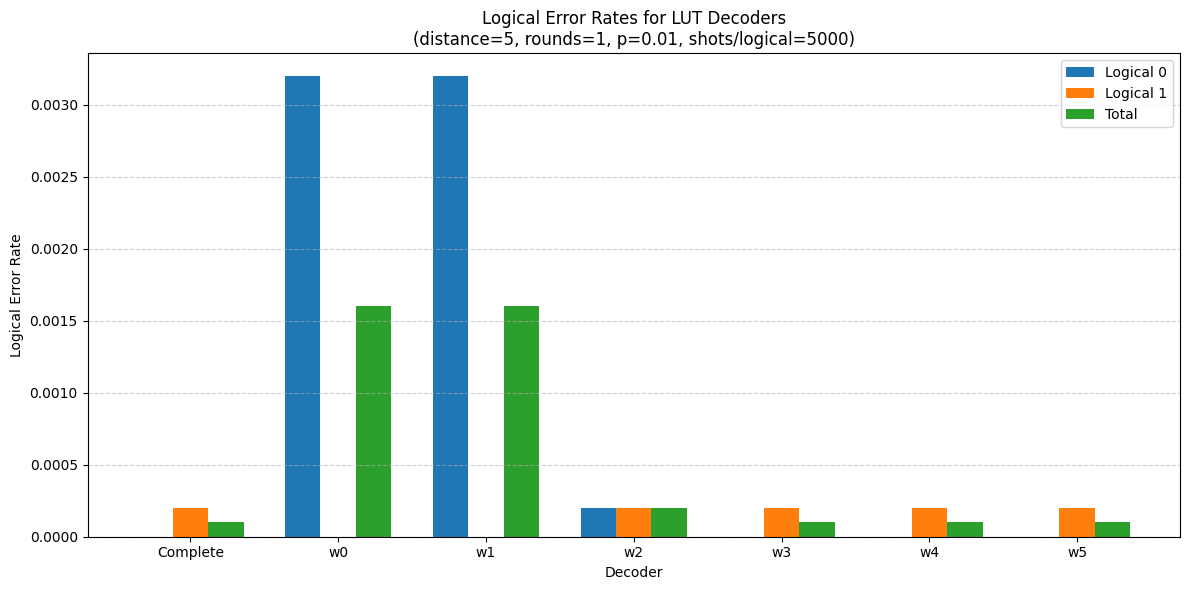

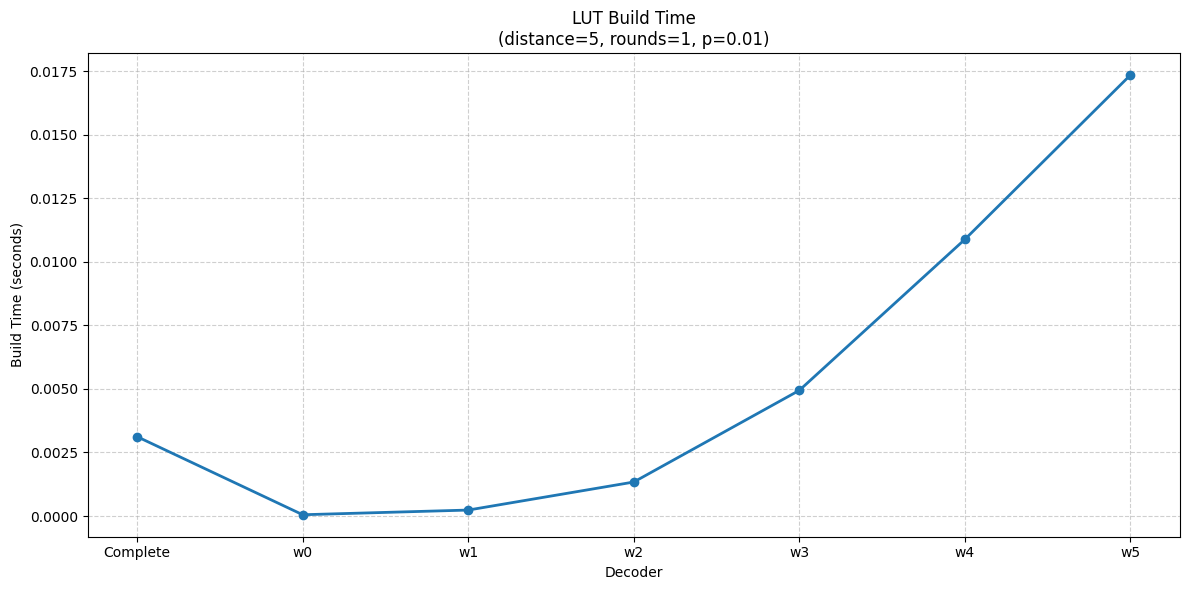

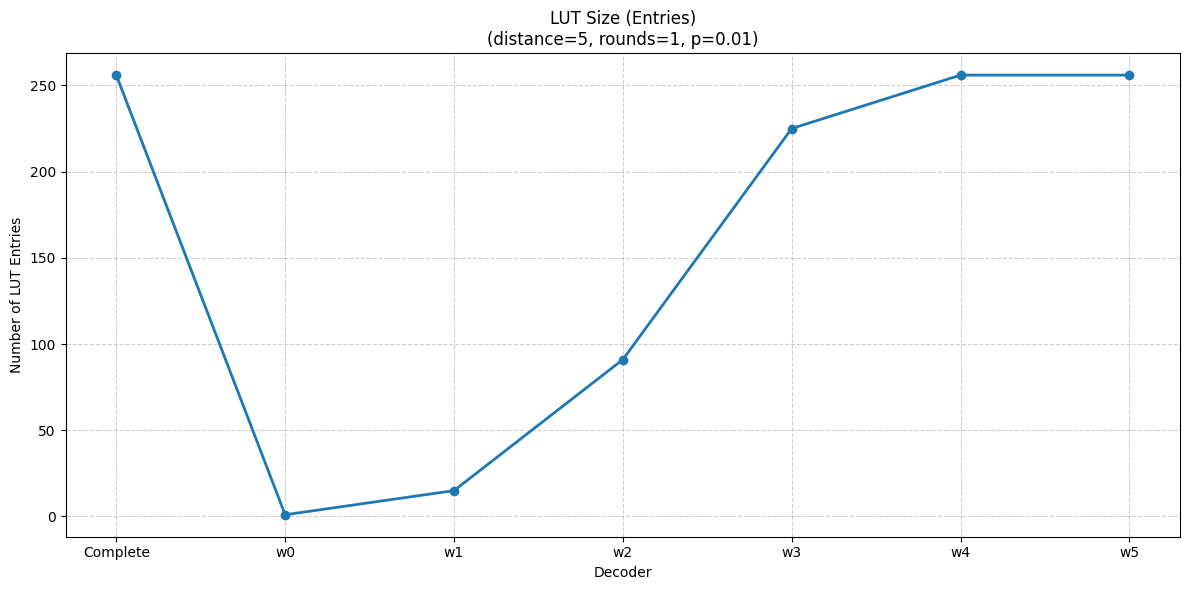

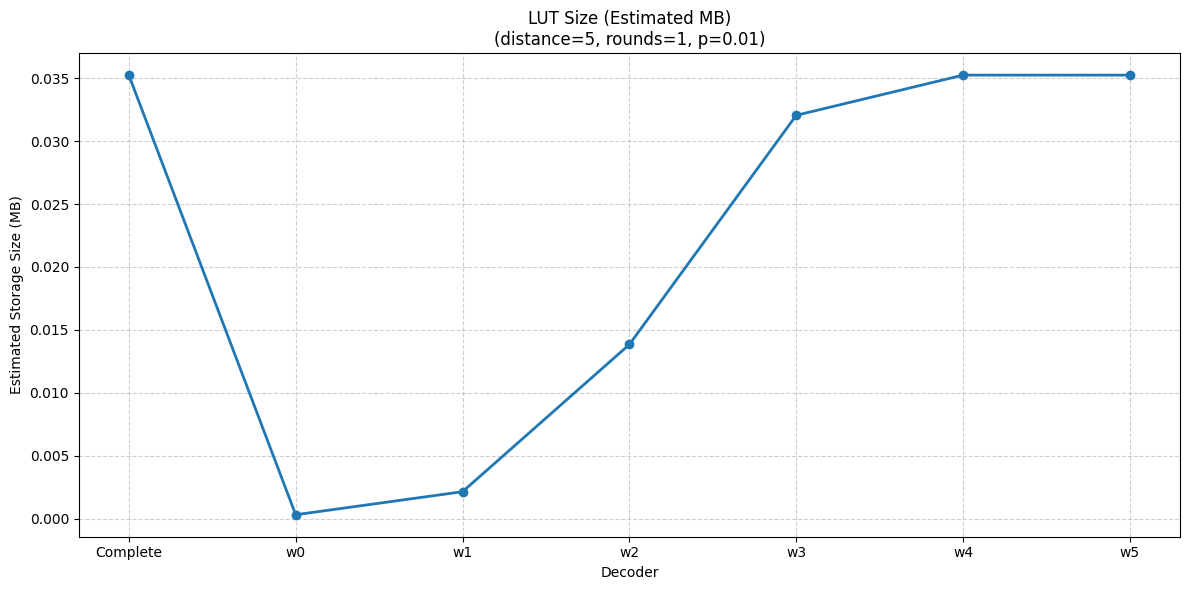

In [12]:
if __name__ == "__main__":
    d = 5
    r = 1
    p = 0.01
    shots_per_logical = 5000
    max_weights = [0, 1, 2, 3, 4, 5]

    results = run_lut_comparison(
        distance=d,
        rounds=r,
        p=p,
        max_weights=max_weights,
        shots_per_logical=shots_per_logical,
    )
    plot_logical_error_bargraph(results, distance=d, rounds=r, p=p, shots_per_logical=shots_per_logical)
    plot_lut_build_time_linegraph(results, distance=d, rounds=r, p=p)
    plot_lut_size_linegraph(results, distance=d, rounds=r, p=p, size_mode="entries")
    plot_lut_size_linegraph(results, distance=d, rounds=r, p=p, size_mode="mb")